<a href="https://colab.research.google.com/github/LeninGF/image-segmentation-tutorials/blob/main/Fine-Tuning-SemanticSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine Tune Semantic Segmentation Model with Custom Dataset

Date: 2026-06-25

Source: https://huggingface.co/blog/fine-tune-segformer

Coder: LeninGF

**Goal**

- To learn how to fine tune a model with a custom dataset
- Test the code in the Ada Lab infrastructure

**About the Tutorial**
- The tutorial uses *SegFormer*
- It uses a dataset from the hub. This can be convenient but does Ada let to connect elsewhere?



## Loading the Dataset

The tutorial uses a dataset that was pushed to the hub

In [1]:
# Login to Hugging Face Hub to access datasets/models
# Generate a read-only token at: https://huggingface.co/settings/tokens
# Store it in a .env file: HF_TOKEN=hf_your_token_here
# Run this cell first before any Hub operations.
from huggingface_hub import login
from pathlib import Path
import os

# Load HF_TOKEN from .env file (no external dependency)
env_path = Path(".env")
if env_path.exists():
    for line in env_path.read_text().splitlines():
        if line.startswith("HF_TOKEN="):
            hf_token = line.split("=", 1)[1].strip().strip("'\"")
            login(token=hf_token, add_to_git_credential=False)
            print("Logged in to Hugging Face Hub successfully.")
            break
    else:
        print("HF_TOKEN not found in .env file.")
        print("Add: HF_TOKEN=hf_your_read_token_here")
else:
    print("No .env file found. Create one with: HF_TOKEN=hf_your_token_here")


No .env file found. Create one with: HF_TOKEN=hf_your_token_here


In [2]:
from datasets import load_dataset

hf_dataset_identifier = "segments/sidewalk-semantic"
ds = load_dataset(hf_dataset_identifier)


README.md:   0%|          | 0.00/4.26k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/324M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
ds = ds.shuffle(seed=1)
ds = ds["train"].train_test_split(test_size=0.2)
train_ds = ds["train"]
test_ds = ds["test"]


Extract the number of labels and the human ids to configure the segmentation model later

In [4]:
import json
from huggingface_hub import hf_hub_download

repo_id = f"datasets/{hf_dataset_identifier}"
filename = "id2label.json"
id2label = json.load(open(hf_hub_download(repo_id=hf_dataset_identifier, filename=filename, repo_type="dataset"), "r"))
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: k for k, v in id2label.items()}

num_labels = len(id2label)


id2label.json:   0%|          | 0.00/852 [00:00<?, ?B/s]

## Image Processing and Data Augmentation

In [5]:
from torchvision.transforms import ColorJitter
from transformers import SegformerImageProcessor

processor = SegformerImageProcessor()
jitter = ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1)

def train_transforms(example_batch):
    images = [jitter(x) for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs


def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs


# Set transforms
train_ds.set_transform(train_transforms)
test_ds.set_transform(val_transforms)


## Loading Model

In [6]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b0"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id
)


config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.classifier.bias                             

Setting up the trainer. However, the original pushes to hub the trained model. Here I disabled that

In [7]:
from transformers import TrainingArguments

# epochs = 50
epochs = 5
lr = 0.00006
batch_size = 16 # 2

hub_model_id = "segformer-b0-finetuned-segments-sidewalk-2"

training_args = TrainingArguments(
    "segformer-b0-finetuned-segments-sidewalk-outputs",
    learning_rate=lr,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=False,
    hub_model_id=hub_model_id,
    hub_strategy="end",
)


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Defining how to evaluate the performance of training

In [8]:
# First, install the 'evaluate' library if it's not already installed.
!pip install evaluate

import torch
from torch import nn
import evaluate

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=len(id2label),
        ignore_index=0,
        reduce_labels=processor.do_reduce_labels,
    )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [9]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)


In [10]:
trainer.train()

Step,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Accuracy Unlabeled,Accuracy Flat-road,Accuracy Flat-sidewalk,Accuracy Flat-crosswalk,Accuracy Flat-cyclinglane,Accuracy Flat-parkingdriveway,Accuracy Flat-railtrack,Accuracy Flat-curb,Accuracy Human-person,Accuracy Human-rider,Accuracy Vehicle-car,Accuracy Vehicle-truck,Accuracy Vehicle-bus,Accuracy Vehicle-tramtrain,Accuracy Vehicle-motorcycle,Accuracy Vehicle-bicycle,Accuracy Vehicle-caravan,Accuracy Vehicle-cartrailer,Accuracy Construction-building,Accuracy Construction-door,Accuracy Construction-wall,Accuracy Construction-fenceguardrail,Accuracy Construction-bridge,Accuracy Construction-tunnel,Accuracy Construction-stairs,Accuracy Object-pole,Accuracy Object-trafficsign,Accuracy Object-trafficlight,Accuracy Nature-vegetation,Accuracy Nature-terrain,Accuracy Sky,Accuracy Void-ground,Accuracy Void-dynamic,Accuracy Void-static,Accuracy Void-unclear,Iou Unlabeled,Iou Flat-road,Iou Flat-sidewalk,Iou Flat-crosswalk,Iou Flat-cyclinglane,Iou Flat-parkingdriveway,Iou Flat-railtrack,Iou Flat-curb,Iou Human-person,Iou Human-rider,Iou Vehicle-car,Iou Vehicle-truck,Iou Vehicle-bus,Iou Vehicle-tramtrain,Iou Vehicle-motorcycle,Iou Vehicle-bicycle,Iou Vehicle-caravan,Iou Vehicle-cartrailer,Iou Construction-building,Iou Construction-door,Iou Construction-wall,Iou Construction-fenceguardrail,Iou Construction-bridge,Iou Construction-tunnel,Iou Construction-stairs,Iou Object-pole,Iou Object-trafficsign,Iou Object-trafficlight,Iou Nature-vegetation,Iou Nature-terrain,Iou Sky,Iou Void-ground,Iou Void-dynamic,Iou Void-static,Iou Void-unclear
20,2.854148,3.022835,0.078662,0.130292,0.574409,nan,0.174704,0.854806,0.003702,0.031970,0.013294,nan,0.000182,0.000000,0.000000,0.687872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.834767,0.000000,0.002710,0.000000,0.000000,nan,0.000000,0.000005,0.000000,0.000000,0.971827,0.012650,0.524236,0.000000,0.000000,0.000000,0.056607,0.000000,0.172363,0.615284,0.003694,0.030815,0.011653,0.000000,0.000182,0.000000,0.000000,0.493153,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.372096,0.000000,0.002541,0.000000,0.000000,0.000000,0.000000,0.000004,0.000000,0.000000,0.505142,0.011593,0.496259,0.000000,0.000000,0.000000,0.038391
40,2.243054,2.231608,0.094847,0.151171,0.638307,nan,0.505536,0.885113,0.000328,0.011247,0.020974,nan,0.000000,0.000000,0.000000,0.718568,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.864735,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.952050,0.100373,0.778547,0.000000,0.000000,0.000000,0.000000,0.000000,0.422037,0.677532,0.000328,0.011221,0.018616,0.000000,0.000000,0.000000,0.000000,0.495033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.419684,0.000000,0.000000,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.594153,0.085493,0.500693,0.000000,0.000000,0.000000,0.000000
60,2.116131,1.920926,0.121633,0.170564,0.684900,nan,0.757207,0.887733,0.000000,0.024462,0.017954,nan,0.000000,0.000000,0.000000,0.804439,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.854382,0.000000,0.000152,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.949291,0.285860,0.876563,0.000000,0.000000,0.000000,0.000000,nan,0.519429,0.711765,0.000000,0.024315,0.017253,nan,0.000000,0.000000,0.000000,0.567175,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.493205,0.000000,0.000152,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.632450,0.249815,0.676681,0.000000,0.000000,0.000000,0.000000
80,1.726871,1.763991,0.140436,0.188462,0.716658,nan,0.799612,0.902712,0.000000,0.043809,0.014663,nan,0.000000,0.000000,0.000000,0.881860,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.870640,0.000000,0.000002,0.000000,0.000000,nan,0.000000,0.000000,0.000000,0.000000,0.919771,0.749292,0.848411,0.000000,0.000000,0.000000,0.000000,nan,0.525499,0.727301,0.000000,0.043197,0.014201,nan,0.0000

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:259: RuntimeWarning: invalid value encountered in divide
  iou = total_area_intersect / total_area_union
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:259: RuntimeWarning: invalid value encountered in divide
  iou = total_area_intersect / total_area_union
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['segformer.stages.0.patch_embeddings.proj.weight', 'segformer.stages.0.patch_embeddings.proj.bias', 'segformer.stages.0.patch_embeddings.layer_norm.weight', 'segformer.stages.0.patch_embeddings.layer_norm.bias', 'segformer.stages.0.blocks.0.layernorm_before.weight', 'segformer.stages.0.blocks.0.layernorm_before.bias', 'segformer.stages.0.blocks.0.attention.q_proj.weight', 'segformer.stages.0.blocks.0.attention.q_proj.bias', 'segformer.stages.0.blocks.0.attention.k_proj.weight', 'segformer.stages.0.blocks.0.attention.k_proj.bias', 'segformer.stages.0.blocks.0.attention.v_proj.weight', 'segformer.stages.0.blocks.0.attention.v_proj.bias', 'segformer.stages.0.blocks.0.attention.o_proj.weight', 'segformer.stages.0.blocks.0.attention.o_proj.bias', 'segformer.stages.0.blocks.0.attention.sequence_reduction.sequence_reduction.weight', 'segformer.stages.0.blocks.0.attention.sequence_reduction.sequence_reduction.bias', 'segfo

TrainOutput(global_step=250, training_loss=1.8633707933425903, metrics={'train_runtime': 1971.1231, 'train_samples_per_second': 2.029, 'train_steps_per_second': 0.127, 'total_flos': 7.0271895601152e+16, 'train_loss': 1.8633707933425903, 'epoch': 5.0})

Pushing to hub

In [11]:
# kwargs = {
#     "tags": ["vision", "image-segmentation"],
#     "finetuned_from": pretrained_model_name,
#     "dataset": hf_dataset_identifier,
# }

# processor.push_to_hub(hub_model_id)
# trainer.push_to_hub(**kwargs)


## Inference
To make predictions we could load the model from the hub but alternative from disk

In [12]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
# model = SegformerForSemanticSegmentation.from_pretrained(f"{hf_username}/{hub_model_id}")


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

In [14]:
from transformers import SegformerForSemanticSegmentation

local_model_path = "/content/segformer-b0-finetuned-segments-sidewalk-outputs/checkpoint-250"
model = SegformerForSemanticSegmentation.from_pretrained(local_model_path)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

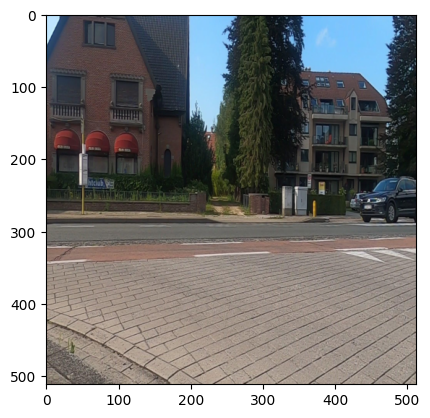

In [21]:
import matplotlib.pyplot as plt
import torch # Added import for torch operations

image = test_ds[0]['pixel_values']
gt_seg = test_ds[0]['labels'] # Changed 'label' to 'labels'

# Get mean and std from the processor for denormalization
# Ensure processor object is available in scope (it is, from cell V8BqI2RMajRQ)
mean_vals = torch.tensor(processor.image_mean).view(1, 1, -1)
std_vals = torch.tensor(processor.image_std).view(1, 1, -1)

# Permute dimensions from (C, H, W) to (H, W, C)
image_display = image.permute(1, 2, 0)

# Denormalize and clip to [0, 1] for proper display
image_display = image_display * std_vals + mean_vals
image_display = image_display.clamp(0, 1)

plt.imshow(image_display.numpy())
plt.show()

In [23]:
from torch import nn

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits  # shape (batch_size, num_labels, height/4, width/4)

# First, rescale logits to original image size
upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size()[1:][::-1], # (height, width) - Corrected to call .size() and get H,W
    mode='bilinear',
    align_corners=False
)

# Second, apply argmax on the class dimension
pred_seg = upsampled_logits.argmax(dim=1)[0]

In [25]:
#@title `def sidewalk_palette()`

def sidewalk_palette():
    """Sidewalk palette that maps each class to RGB values."""
    return [
        [0, 0, 0],
        [216, 82, 24],
        [255, 255, 0],
        [125, 46, 141],
        [118, 171, 47],
        [161, 19, 46],
        [255, 0, 0],
        [0, 128, 128],
        [190, 190, 0],
        [0, 255, 0],
        [0, 0, 255],
        [170, 0, 255],
        [84, 84, 0],
        [84, 170, 0],
        [84, 255, 0],
        [170, 84, 0],
        [170, 170, 0],
        [170, 255, 0],
        [255, 84, 0],
        [255, 170, 0],
        [255, 255, 0],
        [33, 138, 200],
        [0, 170, 127],
        [0, 255, 127],
        [84, 0, 127],
        [84, 84, 127],
        [84, 170, 127],
        [84, 255, 127],
        [170, 0, 127],
        [170, 84, 127],
        [170, 170, 127],
        [170, 255, 127],
        [255, 0, 127],
        [255, 84, 127],
        [255, 170, 127],
    ]

In [28]:
import numpy as np

def get_seg_overlay(image, seg):
  color_seg = np.zeros((seg.shape[0], seg.shape[1], 3), dtype=np.uint8) # height, width, 3
  palette = np.array(sidewalk_palette())
  for label, color in enumerate(palette):
      color_seg[seg == label, :] = color

  # Show image + mask
  img = np.array(image) * 0.5 + color_seg * 0.5
  img = img.astype(np.uint8)

  return img

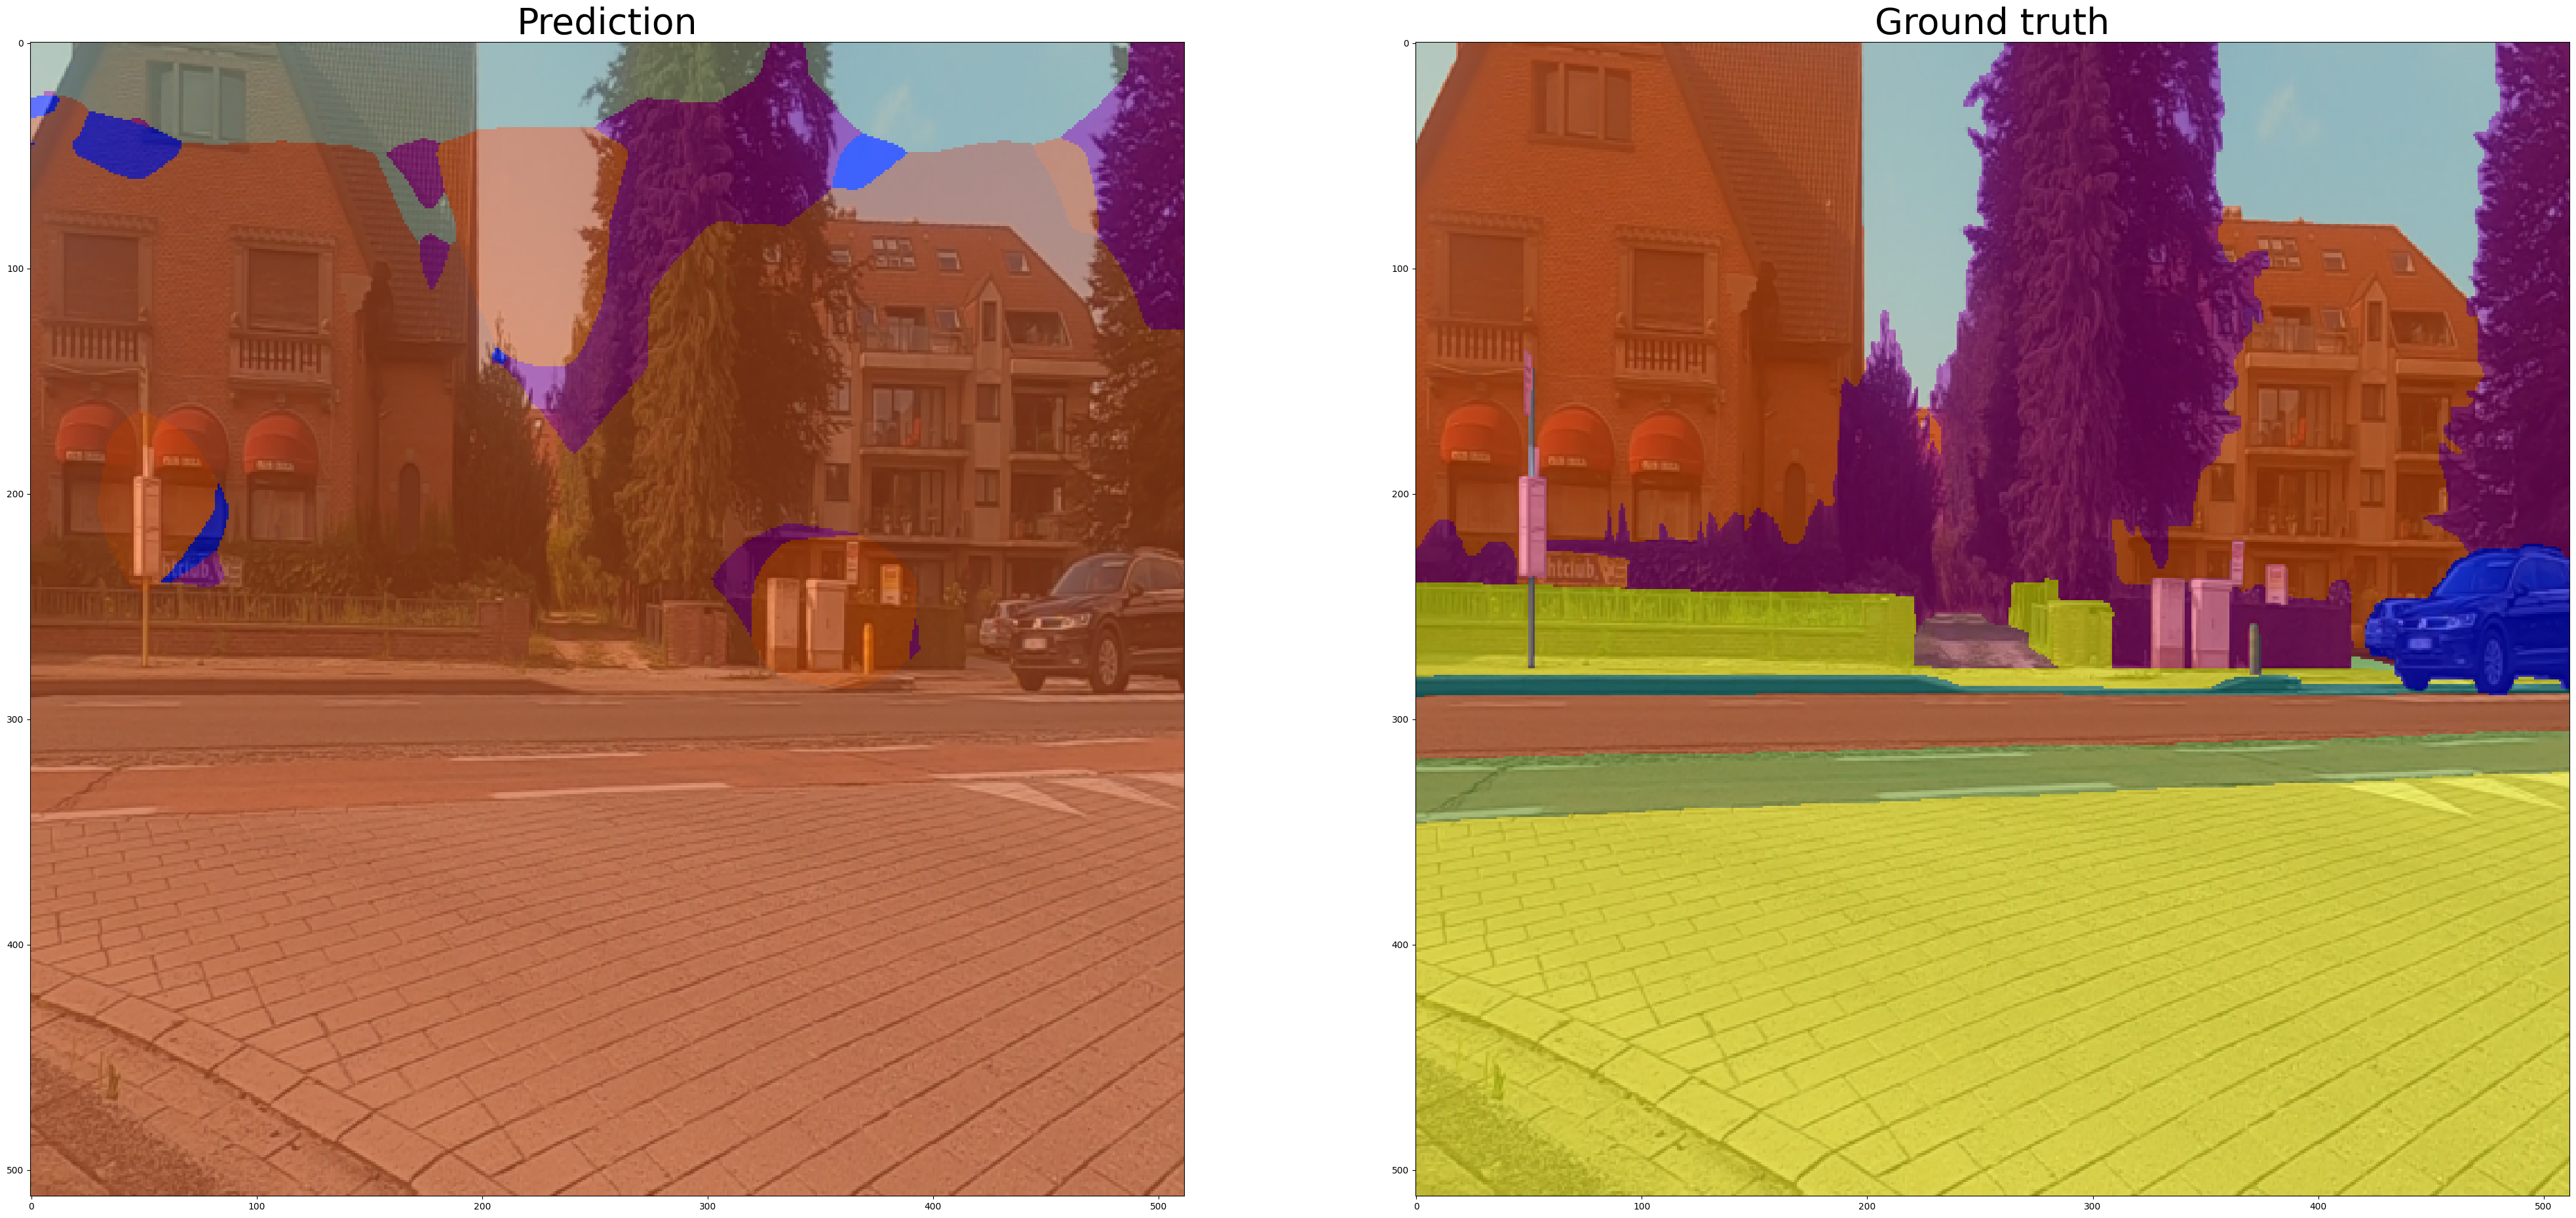

In [29]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for .astype(np.uint8)

# image_display is a torch.Tensor of shape (H, W, C) with values in [0, 1]
# Scale it to [0, 255] and convert to numpy uint8 for overlay
image_for_overlay = (image_display * 255).cpu().numpy().astype(np.uint8)

pred_img = get_seg_overlay(image_for_overlay, pred_seg)
gt_img = get_seg_overlay(image_for_overlay, np.array(gt_seg))

f, axs = plt.subplots(1, 2)
f.set_figheight(30)
f.set_figwidth(50)

axs[0].set_title("Prediction", {'fontsize': 40})
axs[0].imshow(pred_img)
axs[1].set_title("Ground truth", {'fontsize': 40})
axs[1].imshow(gt_img)

In [30]:
import shutil
import os

folder_to_zip = '/content/segformer-b0-finetuned-segments-sidewalk-outputs/checkpoint-250'
output_filename = 'checkpoint-250'

# Create the zip archive
shutil.make_archive(output_filename, 'zip', folder_to_zip)

print(f"Folder '{folder_to_zip}' has been zipped to '{output_filename}.zip'")
print(f"You can now download '{output_filename}.zip'")

Folder '/content/segformer-b0-finetuned-segments-sidewalk-outputs/checkpoint-250' has been zipped to 'checkpoint-250.zip'
You can now download 'checkpoint-250.zip'
